# A3. Classification [86 pts]

The objective of the **Assignment 3** is to:
* Review classification models: Random Forest, Gradient Boosting Tree, Naive Bayes
* Perform feature selection using iterative methods and PCA

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

# Dataset

For this assignment, we will use the `Weekly S&P Stock Market Data`. This dataset contains the weekly percentage returns for the S&P 500 stock index between 1990 and 2010. The following is the description of the variables:

* Year: The year that the observation was recorded
* Lag1: Percentage return for previous week
* Lag2: Percentage return for 2 weeks previous
* Lag3: Percentage return for 3 weeks previous
* Lag4: Percentage return for 4 weeks previous
* Lag5: Percentage return for 5 weeks previous
* Volume: Volume of shares traded (average number of daily shares traded in billions)
* Today: Percentage return for this week
* Direction: A factor with levels ‘Down’ and ‘Up’ indicating whether the market had a positive or negative return on a given week.

Source: Raw values of the S&P 500 were obtained from Yahoo Finance and then converted to percentages and lagged.

In [2]:
Weekly = pd.read_csv('Weekly.csv')
Weekly.shape

(1089, 9)

In [3]:
Weekly.head(10)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
5,1990,1.178,0.712,3.514,-2.576,-0.270,0.154444,-1.372,Down
6,1990,-1.372,1.178,0.712,3.514,-2.576,0.151722,0.807,Up
7,1990,0.807,-1.372,1.178,0.712,3.514,0.132310,0.041,Up
8,1990,0.041,0.807,-1.372,1.178,0.712,0.143972,1.253,Up
9,1990,1.253,0.041,0.807,-1.372,1.178,0.133635,-2.678,Down


# Splitting data into training and set

For this assignment, we will train our models using data from 1990 to 2005. The validation set will include data from 2006 to 2009. Finally, the test set will include data corresponding to 2010.

The purpose will be to predict the variable `Direction`, which indicates if the SP&500 index went down or up that week. We will use the five lag variables plus volume as predictors.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

cols =Weekly.columns[1:-2]

X_train = Weekly.loc[ Weekly['Year'] < 2006 ][ cols ]
X_val = Weekly.loc[ ( Weekly['Year'] >= 2006) &  ( Weekly['Year'] < 2010) ][ cols ]
X_test = Weekly.loc[  Weekly['Year'] >= 2010][ cols ]

X_test_actual = Weekly.loc[  Weekly['Year'] >= 2010, 'Today' ]


y_train = Weekly.loc[ Weekly['Year'] < 2006 ]['Direction'].replace({'Down':0, 'Up':1}).values
y_val = Weekly.loc[ ( Weekly['Year'] >= 2006) &  ( Weekly['Year'] < 2010) ]['Direction'].replace({'Down':0, 'Up':1}).values
y_test = Weekly.loc[ Weekly['Year'] >= 2010 ]['Direction'].replace({'Down':0, 'Up':1}).values
    

print( X_train.shape, X_val.shape, X_test.shape )
print( y_train.shape, y_val.shape, y_test.shape )

(828, 6) (209, 6) (52, 6)
(828,) (209,) (52,)


In [5]:
X_train.head()

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume
0,0.816,1.572,-3.936,-0.229,-3.484,0.154976
1,-0.270,0.816,1.572,-3.936,-0.229,0.148574
2,-2.576,-0.270,0.816,1.572,-3.936,0.159837
3,3.514,-2.576,-0.270,0.816,1.572,0.161630
4,0.712,3.514,-2.576,-0.270,0.816,0.153728


## Imbalanced dataset

Before going to the training stage, let's check how is the distribution of the classes in the training set.

In [6]:
pd.Series(y_train).value_counts() / len(y_train)

1    0.559179
0    0.440821
Name: count, dtype: float64

Class 1 (Up) overpasses the number of samples with class 0. This imbalance between classes can affect the training of our models. To overcome this, we can use the oversampling technique, sampling with the replacement of the minority class, so that both of them have a similar proportion. To read more, please check this: https://en.wikipedia.org/wiki/Oversampling_and_undersampling_in_data_analysis

In Python, we can use the class SMOTE from the imblearn.over_sampling library for such purpose.   https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

In [7]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42  )

# Ensure y_train is integer type for SMOTE
y_train = y_train.astype(int)

# Apply SMOTE to the dataset
X_train_over, y_train = smote.fit_resample( X_train, y_train )

#ros = RandomOverSampler(random_state=42)
#X_train_over, y_train = ros.fit_resample( X_train, y_train )

If we check again the proportion, now we see that they have similar proportion.

In [8]:
pd.Series(y_train).value_counts() / len(y_train)

0    0.5
1    0.5
Name: count, dtype: float64

## Normalizing features

Finally, we normalize the features using the StandardScaler.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_over)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



# Visualizing using PCA

The current dataset has a total of six features, which makes challenging to visualize.

So, we will use PCA to reduce dimensionality into two PCA.

**[5 pts]** Apply PCA to the `X_train_scaled` to find the principal components. You can use the in-built PCA library.

In [10]:
from sklearn.decomposition import PCA

# TO DO
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

**[5 pts]** Make a scatter plot, locating the principal component on the x-axis and the second component on the y-axis. For the *Down* samples, use 'v' as a marker and 'r' as a color. For the *Up* samples, use '^' as a marker and 'g' as a color.

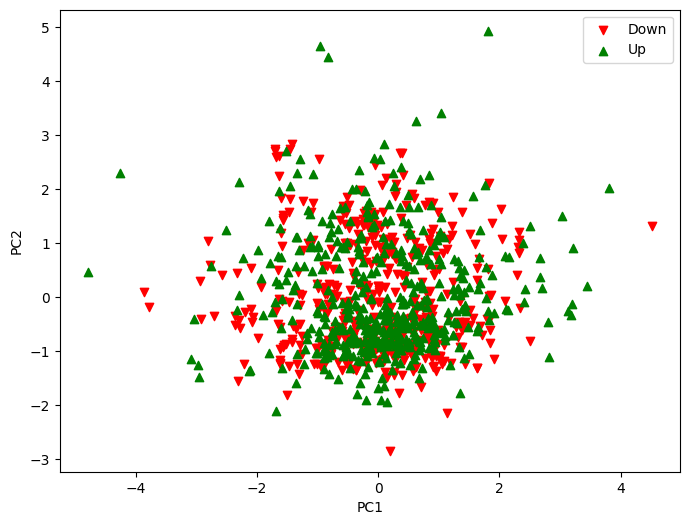

In [11]:
# TO DO
plt.figure(figsize=(8,6))

mask_down = y_train == 0
mask_up = y_train == 1

plt.scatter(X_train_pca[mask_down, 0], X_train_pca[mask_down, 1], marker='v', c='r', label='Down')
plt.scatter(X_train_pca[mask_up, 0], X_train_pca[mask_up, 1], marker='^', c='g', label='Up')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend()

plt.show()

**[4 pts]** Calculate how many components are need to keep at least 80% of the data.

In [12]:
#TO DO
pca_full = PCA()
pca_full.fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Components for 80% variance: {n_components_80}")


Components for 80% variance: 5


**[4 pts]** Train a Logistic regression using the number of components identified in the previous question. Test the model into the test set. To transform the test set use: `X_test_pca = pca.transform( X_test_scaled )`, where pca is the PCA object you fit into the training data.



In [13]:
from sklearn.linear_model import LogisticRegression

# TO DO
pca = PCA(n_components=n_components_80)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

lr = LogisticRegression()
lr.fit(X_train_pca, y_train)
pred = lr.predict(X_test_pca)

y_test = y_test.astype(int)

In [14]:
confusion_matrix( y_test, pred )

array([[12,  8],
       [19, 13]])

# Selecting features backward search

[**8 pts**] As we saw in class, we can also select features using an iterative procedure. The code below performs feature selection using a backward search. Complete the missing parts.

As a metric we will use G-mean. This metric is defined as:
$$G-mean = \sqrt{ TPR \times TNR }, $$ where TPR is the true positive rate (percentage of samples from the positive class predicted correctly), and TNR is the true positive rate (percentage of samples from the negative class predicted correctly)

In [15]:
from sklearn.metrics import f1_score

#Total number of features. Initially it will contain six values: [0 1 2 3 4 5 ], each representing a feature
features = np.arange( X_train_scaled.shape[1] ).tolist()
selected = []

stop = False

y_val = y_val.astype(int)

#First we train a logistic regression, using all the features
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train )

pred = clf.predict( X_val_scaled )

# TO DO 
# Calculate the g-mean
cm = confusion_matrix( y_val, pred ) 
cm = cm/np.sum( cm, axis=1)[:,np.newaxis]
gmean = np.sqrt( cm[0,0]*cm[1,1] )

prevGmean = gmean

while not stop:
    
    # Array to store gmean obtained by removing each feature
    gmean_values = np.empty( len(features) ) 
    

    for idxF in range( len( features ) ):
        
        #getting current feature
        currentF = features[idxF ]
        
        # making a copy of the still features
        remainingFeat = features.copy()
        # remove the current feature
        remainingFeat.remove( currentF )
        
        # TO DO 
        # Train logistic regression using the X_train_scaled[:, remainingFeat]
        clf = LogisticRegression()
        clf.fit(X_train_scaled[:, remainingFeat], y_train )
        # Calculate Gmean using  X_val_scaled[: ,remainingFeat ] 
        pred = clf.predict( X_val_scaled[:, remainingFeat ] )
        cm = confusion_matrix( y_val, pred )
        cm = cm/np.sum( cm, axis=1)[:,np.newaxis]
        gmean = np.sqrt( cm[0,0]*cm[1,1])
        
        
        gmean_values[ idxF ] = gmean 
        
        print( cols[ remainingFeat],  gmean_values[ idxF ] )
        idxF += 1 
        
    idxMin = np.argmax( gmean_values ) 
    dropFeat = features[ idxMin ] 
    
    # TO DO
    # write the condition that check if the feature can be dropped
    if gmean_values[ idxMin ] >= prevGmean:
        prevGmean = gmean_values[ idxMin ]
        features.remove( dropFeat )
    else:
        stop = True
    
    print( dropFeat,  gmean_values[ idxMin ] )
        
        
print( cols[ features] )

Index(['Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume'], dtype='str') 0.4498749953914093
Index(['Lag1', 'Lag3', 'Lag4', 'Lag5', 'Volume'], dtype='str') 0.30424000964875475
Index(['Lag1', 'Lag2', 'Lag4', 'Lag5', 'Volume'], dtype='str') 0.46205911157505775
Index(['Lag1', 'Lag2', 'Lag3', 'Lag5', 'Volume'], dtype='str') 0.4449492083146097
Index(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Volume'], dtype='str') 0.39521936580516653
Index(['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'], dtype='str') 0.5222329678670935
5 0.5222329678670935
Index(['Lag2', 'Lag3', 'Lag4', 'Lag5'], dtype='str') 0.4839005885657973
Index(['Lag1', 'Lag3', 'Lag4', 'Lag5'], dtype='str') 0.5020618644176028
Index(['Lag1', 'Lag2', 'Lag4', 'Lag5'], dtype='str') 0.5126498974498794
Index(['Lag1', 'Lag2', 'Lag3', 'Lag5'], dtype='str') 0.4883397032275719
Index(['Lag1', 'Lag2', 'Lag3', 'Lag4'], dtype='str') 0.5366289362709977
4 0.5366289362709977
Index(['Lag2', 'Lag3', 'Lag4'], dtype='str') 0.5077905470461433
Index(['Lag1', 'Lag3', 'Lag4'], dtype='st

**[4 pts]** Using the best identified features, train a logisitc regression and evaluate on the test set

In [16]:
# TO DO
clf = LogisticRegression()
clf.fit(X_train_scaled[:, features], y_train )

pred = clf.predict( X_test_scaled[:, features] )

cm = confusion_matrix( y_test, pred )
print( cm )

[[12  8]
 [13 19]]


# Visualizing importance using a Random Forest

We can also analyze which are the relevant features by training a random forest and then checking the feature relevance.  

**[5 pts]** Train a Random Forest using the default parameters. Then make a bar plot of the feature importance.

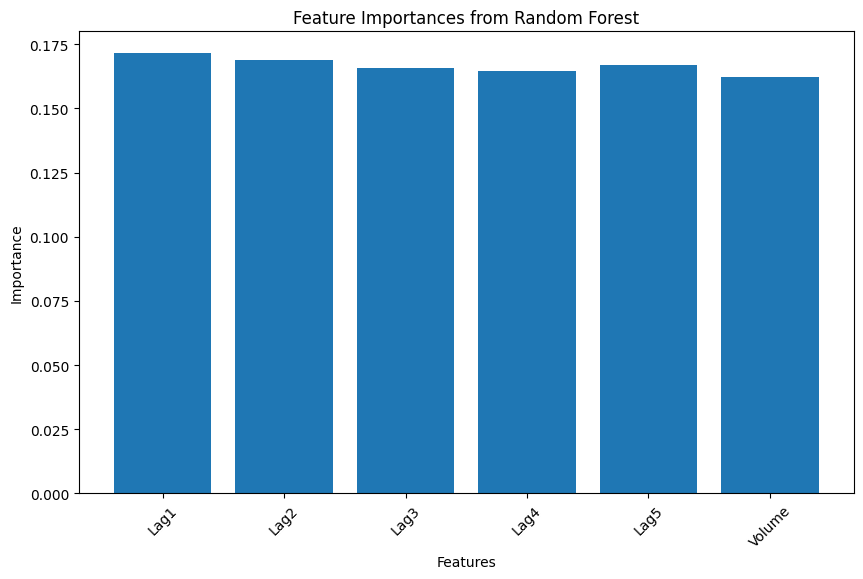

In [17]:
from sklearn.ensemble import RandomForestClassifier

# TO DO
rf = RandomForestClassifier(random_state=0)
rf.fit(X_train_scaled, y_train )

plt.figure(figsize=(10,6))
plt.bar(range(len(cols)), rf.feature_importances_)
plt.xticks(range(len(cols)), cols)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances from Random Forest')
plt.xticks(rotation=45)
plt.show()


   # Comparison Analysis

Now, we want to train three different classifiers:
- Random Forest
- XGBoost
- Naive Bayes


For each classifiers, we will tune the hyperparameters.

### Random Forest

**[8 pts]** Complete the hyperparameter tuning for the Random forest. 

For reproducibility, please include the set `random_state =0` inside the random forest object.

Use Gmean as the metric factor to compare the hyperparameter configurations.

You need to fit the model on the training data and evaluate the validation set.

In [18]:
from itertools import product


# Define the parameter space
space = {
    'n_estimators': [ 50, 80, 100, 300  ],
    'max_depth': [1, 2, 3, 4, 5 ],
    'min_samples_leaf': [ 5, 7,  10],
    'max_features': [.3, .4, .5 ]
}


        

# Compute the Cartesian product
cartesian_product = list(product(*space.values()))

maxScore = 0
bestCombination_rf = None
rf = None 

# Print the Cartesian product
for combination in cartesian_product:        
    n_estimators = combination[0]
    max_depth = combination[1]
    min_samples_leaf = combination[2]
    max_features = combination[3]
    
    
    # TO DO 
    #1. Define a random forest
    #2. Fit using X_train_scaled, y_train
    #3. predict on X_val_scaled
    #4. calculate gmean
    # 5. update best combionation if needed
    rf = RandomForestClassifier( n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features, random_state=0 )
    rf.fit(X_train_scaled, y_train )
    pred = rf.predict(X_val_scaled)
    cm = confusion_matrix( y_val, pred )
    cm = cm/np.sum( cm, axis=1)[:,np.newaxis]
    gmean = np.sqrt( cm[0,0]*cm[1,1])


    if gmean > maxScore:
        maxScore = gmean
        bestCombination_rf = combination
        print( 'hyperparameters:{}, gmean :{}'.format(combination, gmean ))
        print( cm )
        
        

        
    
print('best combination for randome forest')
print( bestCombination_rf )
    

hyperparameters:(50, 1, 5, 0.3), gmean :0.4889974000956196
[[0.42424242 0.57575758]
 [0.43636364 0.56363636]]
hyperparameters:(50, 1, 5, 0.4), gmean :0.49236596391733095
[[0.48484848 0.51515152]
 [0.5        0.5       ]]
hyperparameters:(50, 1, 5, 0.5), gmean :0.49478455301541396
[[0.43434343 0.56565657]
 [0.43636364 0.56363636]]
hyperparameters:(50, 1, 10, 0.3), gmean :0.5005047956863655
[[0.44444444 0.55555556]
 [0.43636364 0.56363636]]
hyperparameters:(100, 1, 5, 0.4), gmean :0.5019704058387553
[[0.49494949 0.50505051]
 [0.49090909 0.50909091]]
best combination for randome forest
(100, 1, 5, 0.4)


**[4 pts]** Use the best parameters to fit the final model. Then, check the accuracy of the test set.

Please store the prediction of the test set into a variable called `pred_rf`.

For reproducibility, please include the set `random_state =0` inside the random forest object.

Print the confusion matrix (cm)

In [19]:
n_estimators = bestCombination_rf[0]
max_depth = bestCombination_rf[1]
min_samples_leaf = bestCombination_rf[2]
max_features = bestCombination_rf[3]


# TO DO
rf = RandomForestClassifier( n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features, random_state=0 )
rf.fit(X_train_scaled, y_train )
pred_rf = rf.predict(X_test_scaled)
cm = confusion_matrix( y_test, pred_rf )
print( cm )

[[13  7]
 [15 17]]


### Gradient Boosting Tree

**[8 pts]** Complete the hyperparameter tuning for the Gradient Boosting Tree. Use the sklearn version: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

For reproducibility, please include the set `random_state =0` inside the gradient boositing tree object.

Use Gmean as the metric factor to compare the hyperparameter configurations.

You need to fit the model on the training data and evaluate the validation set.



In [20]:
from sklearn.ensemble import GradientBoostingClassifier


# Define the parameter space
space = dict()
space['n_estimators'] = [10, 15, 20 ]
space['max_depth'] = [1, 2, 3, 4, 5 ]
space['min_samples_leaf'] =   [ 5, 10, 20 ]
space['max_features'] = [.2,.3,.4,.5]
space['learning_rate'] = [ .1, .5, 1 ]


# Compute the Cartesian product
cartesian_product = list(product(*space.values()))

maxScore = 0
bestCombination_gb = None
rf = None 
# Print the Cartesian product
for combination in cartesian_product:
    
    
    n_estimators = combination[0]
    max_depth = combination[1]
    min_samples_leaf = combination[2]
    max_features = combination[3]
    learning_rate  = combination[4]
    
    
      # TO DO 
    #1. Define a gradient boosting 
    #2. Fit using X_train_scaled, y_train
    #3. predict on X_val_scaled
    #4. calculate gmean
    # 5. update best combionation if needed
    gb = GradientBoostingClassifier( n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features, learning_rate=learning_rate, random_state=0 )
    gb.fit(X_train_scaled, y_train )
    pred = gb.predict(X_val_scaled)

    cm = confusion_matrix( y_val, pred )
    cm = cm/np.sum( cm, axis=1)[:,np.newaxis]
    gmean = np.sqrt( cm[0,0]*cm[1,1])
    
    if gmean > maxScore:
        maxScore = gmean
        bestCombination_gb = combination
        print( 'hyperparameters:{}, gmean :{}'.format(combination, gmean ))
        print( cm )
        
        

    
print('best combination for Gradient Boosting tree')
print( bestCombination_gb )

hyperparameters:(10, 1, 5, 0.2, 0.1), gmean :0.4146092454905956
[[0.78787879 0.21212121]
 [0.78181818 0.21818182]]
hyperparameters:(10, 1, 5, 0.2, 0.5), gmean :0.5022447316115806
[[0.41414141 0.58585859]
 [0.39090909 0.60909091]]
hyperparameters:(10, 1, 5, 0.2, 1), gmean :0.5255632336649405
[[0.47474747 0.52525253]
 [0.41818182 0.58181818]]
hyperparameters:(10, 1, 10, 0.2, 1), gmean :0.5581025179743679
[[0.53535354 0.46464646]
 [0.41818182 0.58181818]]
hyperparameters:(10, 1, 20, 0.2, 0.5), gmean :0.5652957001872009
[[0.58585859 0.41414141]
 [0.45454545 0.54545455]]
best combination for Gradient Boosting tree
(10, 1, 20, 0.2, 0.5)


**[4 pts]** Use the best parameters to fit the final model. Then, check the accuracy of the test set.

Please store the prediction of the test set into a variable called `pred_gb`.

For reproducibility, please include the set `random_state =0` inside the gradient boositing tree object.

Print the confusion matrix

In [21]:
n_estimators = bestCombination_gb[0]
max_depth = bestCombination_gb[1]
min_samples_leaf = bestCombination_gb[2]
max_features = bestCombination_gb[3]
learning_rate  = bestCombination_gb[4]
    
# TO DO
gb = GradientBoostingClassifier( n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features, learning_rate=learning_rate, random_state=0 )
gb.fit(X_train_scaled, y_train )
pred_gb = gb.predict(X_test_scaled)

cm = confusion_matrix( y_test, pred_gb )

print( cm )

[[15  5]
 [12 20]]


# Naive Bayes

**[8 pts]** Complete the hyperparameter tuning for the Naive Bayes. 

We will use the inbuilt library from sklearn: GaussianNB
https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


Use Gmean as the metric factor to compare the hyperparameter configurations.

You need to fit the model on the training data and evaluate the validation set.

In [22]:
from sklearn.naive_bayes import GaussianNB

space = dict()
space['priors']  = np.linspace(.2,.8, 20)
space['var_smoothing'] =  np.logspace(-20, 0, num=100) 



# Compute the Cartesian product
cartesian_product = list(product(*space.values()))

maxScore = 0
bestCombination_nb = None

# Print the Cartesian product
for combination in cartesian_product:
    
    priors = combination[0]
    priors = np.asarray([priors, 1-priors])
    var_smoothing = combination[1]
    
      # TO DO 
    #1. Define a GB 
    #2. Fit using X_train_scaled, y_train
    #3. predict on X_val_scaled
    #4. calculate gmean
    # 5. update best combionation if needed
    nb = GaussianNB( priors=priors, var_smoothing=var_smoothing )
    nb.fit(X_train_scaled, y_train )
    pred = nb.predict(X_val_scaled)
    cm = confusion_matrix( y_val, pred )
    cm = cm/np.sum( cm, axis=1)[:,np.newaxis]
    gmean = np.sqrt( cm[0,0]*cm[1,1])
    
    if gmean > maxScore:
        maxScore = gmean
        bestCombination_nb = combination
        print( 'hyperparameters:{}, gmean :{}'.format(combination, gmean ))
        print( cm )
        
        
            
print('best combination for gausinan bayes')
print( bestCombination_nb )




hyperparameters:(np.float64(0.4526315789473685), np.float64(1e-20)), gmean :0.10050378152592121
[[0.01010101 0.98989899]
 [0.         1.        ]]
hyperparameters:(np.float64(0.48421052631578954), np.float64(1e-20)), gmean :0.14083575804390608
[[0.02020202 0.97979798]
 [0.01818182 0.98181818]]
hyperparameters:(np.float64(0.48421052631578954), np.float64(0.2477076355991714)), gmean :0.17248787237282068
[[0.03030303 0.96969697]
 [0.01818182 0.98181818]]
hyperparameters:(np.float64(0.48421052631578954), np.float64(0.39442060594376477)), gmean :0.22268088570756164
[[0.05050505 0.94949495]
 [0.01818182 0.98181818]]
hyperparameters:(np.float64(0.48421052631578954), np.float64(0.6280291441834273)), gmean :0.2585542910024429
[[0.07070707 0.92929293]
 [0.05454545 0.94545455]]
hyperparameters:(np.float64(0.48421052631578954), np.float64(1.0)), gmean :0.3194060143770026
[[0.11111111 0.88888889]
 [0.08181818 0.91818182]]
hyperparameters:(np.float64(0.5157894736842106), np.float64(0.247707635599171

**[4 pts]** Use the best parameters to fit the final model. Then, check the accuracy of the test set.

Please store the prediction of the test set into a variable called `pred_nb`.

Print confusion matrix
   

In [ ]:
priors = bestCombination_nb[0]
priors = np.asarray([priors, 1-priors])
var_smoothing = bestCombination_nb[1]

# TO DO
nb = GaussianNB( priors=priors, var_smoothing=var_smoothing )
nb.fit(X_train_scaled, y_train )
pred_nb = nb.predict(X_test_scaled)
cm = confusion_matrix( y_test, pred_nb )
print( cm )

# For Random Forest (pred_rf)
cm_rf = confusion_matrix(y_test, pred_rf)
cm_rf_norm = cm_rf / cm_rf.sum(axis=1)[:, np.newaxis]
rf_down = cm_rf_norm[0, 0] * 100
rf_up = cm_rf_norm[1, 1] * 100
rf_gmean = np.sqrt(cm_rf_norm[0, 0] * cm_rf_norm[1, 1]) * 100

# For Gradient Boosting (pred_gb)
cm_gb = confusion_matrix(y_test, pred_gb)
cm_gb_norm = cm_gb / cm_gb.sum(axis=1)[:, np.newaxis]
gb_down = cm_gb_norm[0, 0] * 100
gb_up = cm_gb_norm[1, 1] * 100
gb_gmean = np.sqrt(cm_gb_norm[0, 0] * cm_gb_norm[1, 1]) * 100

# For Naive Bayes (pred_nb)
cm_nb = confusion_matrix(y_test, pred_nb)
cm_nb_norm = cm_nb / cm_nb.sum(axis=1)[:, np.newaxis]
nb_down = cm_nb_norm[0, 0] * 100
nb_up = cm_nb_norm[1, 1] * 100
nb_gmean = np.sqrt(cm_nb_norm[0, 0] * cm_nb_norm[1, 1]) * 100

print(f"RF: Down={rf_down:.2f}%, Up={rf_up:.2f}%, G-Mean={rf_gmean:.2f}%")
print(f"GB: Down={gb_down:.2f}%, Up={gb_up:.2f}%, G-Mean={gb_gmean:.2f}%")
print(f"NB: Down={nb_down:.2f}%, Up={nb_up:.2f}%, G-Mean={nb_gmean:.2f}%")


[[ 5 15]
 [12 20]]
RF: Down=65.00%, Up=53.12%, G-Mean=58.76%
GB: Down=75.00%, Up=62.50%, G-Mean=68.47%
NB: Down=25.00%, Up=62.50%, G-Mean=39.53%


**[5 pts]** Based on your results, complete the following table

| Model | Downward Accuracy (%) | Upward Accuracy (%) | G-Mean (%) |
|-------|-----------------------|---------------------|------------|
| RF    |      65.00%    |    53.12%    | 58.76% |
| GB    |      75.00%    |    62.50    | 68.47% |
| NB   |      25.00%    |    62.50%    | 39.53 |

### Provide interpretation of the results.

Gradient Boosting performs best with the highest G-mean (68.47%), showing it best balances predicting both market directions. Naive Bayes performs worst, especially for downward predictions (25%), as the feature independence assumption doesn't hold for stock market data.

# Checking Stock performance

In addition to the model accuracy, we can compare the models to evaluate which could obtain a better return.

The variable `X_test_actual` contains the actual return. To evaluate the models, let's use a simple investment strategy. We would buy when the model output is 1, and we do not buy otherwise.

**[4 pts]** Calculate the return of each classifier by multiplying the prediction made for each classifier with the `X_test_actual` vector.

In [24]:
# TO DO
return_rf = pred_rf * X_test_actual 
return_gb = pred_gb * X_test_actual 
return_nb = pred_nb * X_test_actual

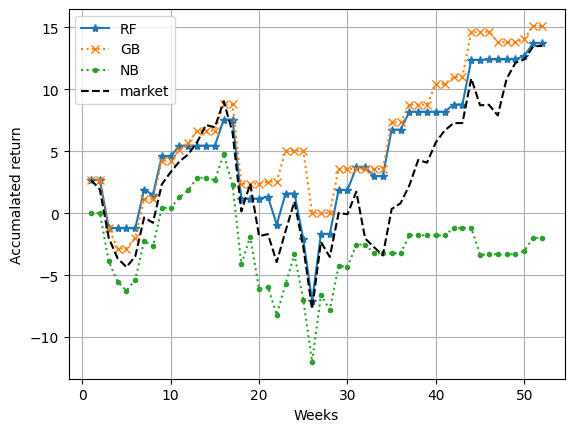

In [25]:
weeks = np.arange(1,53)


plt.figure()
plt.plot( weeks, np.cumsum(  return_rf), '*-', label = 'RF')
plt.plot( weeks, np.cumsum( return_gb ), 'x:', label = 'GB')
plt.plot( weeks, np.cumsum(  return_nb), ':.', label = 'NB')
plt.plot( weeks, np.cumsum(  X_test_actual ), 'k--', label = 'market')
plt.xlabel('Weeks')
plt.ylabel('Accumalated return')
plt.grid()
plt.legend()




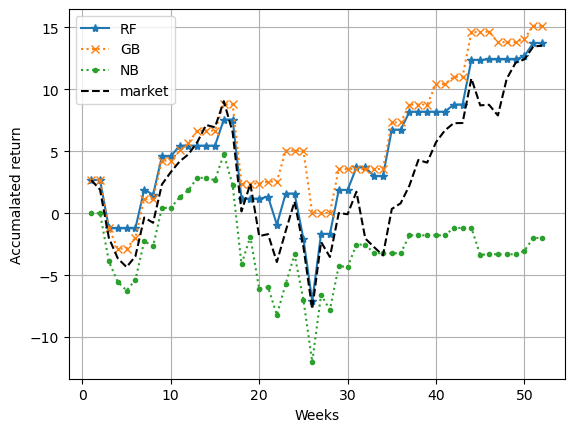

Complete the table, providing the accumlated interest obtain at the 52th week of 2010.

| Model | Accumulated interest (%)  |
|-------|-----------------------|
| RF    |      14.00%     |
| GB    |      15.00%    |
| NB   |      -3.00%     |

[**6pts]** Provide interpretation. Which model was the best one? Based on the predictive performance, what could be the reason that that model performs better than the others? Did the model perform better than just buying shares of the index fund every week (black dotted line)?

The Gradient Boosting model has the best performance, followed by the Random Forest model, leaving the Naive Bayes model to be the last and the worst performing model. The Gradient Boosting model is the best because it has the highest gmean, which shows that it has a good balance between sensitivity and specificity. The Random Forest model is the second best because it also has a high gmean, but it is not as high as the Gradient Boosting model. The Naive Bayes model is the worst because it has the lowest gmean, which indicates that it has a poor balance between sensitivity and specificity. The Gradient Boosting model did perform better than just buying index funds shares every week. 